> # Tutorial: Linear Programming Basics
Learning goals:
- Understand what an objective function and constraints are.
- See why optimal solutions often occur at corner points.
- Solve a few toy examples with plain Python and an optional SciPy solver.


## Outline

1. What linear programming is
2. A helper for 2-variable toy problems
3. Example 1: product mix maximization
4. Example 2: advertising budget allocation
5. Example 3: diet-style cost minimization
6. Optional: solving one problem with `scipy.optimize.linprog`
7. Exercises and common pitfalls


## What is Linear Programming?

A linear program chooses values for decision variables to optimize a linear objective, while satisfying linear constraints.

A typical form is:

- Maximize or minimize `c1*x1 + c2*x2 + ...`
- Subject to rules like `a1*x1 + a2*x2 <= b`
- And often non-negativity constraints such as `x1 >= 0`, `x2 >= 0`

For small 2-variable problems, we can often reason about the feasible region and test its corner points.


### What the symbols mean

The compact LP notation can feel abstract at first, so here is the meaning of each symbol.

- `x1`, `x2`, ... are the **decision variables**. These are the unknown quantities we want to choose. In a business example, they might mean how many units of each product to make.
- `c1`, `c2`, ... are the **objective coefficients**. They tell us how much each variable contributes to the objective. For example, if profit is `40x + 30y`, then the coefficients are 40 and 30.
- `a1`, `a2`, ... are the **constraint coefficients**. They describe how much of a resource each variable uses inside one constraint.
- `b` is the **limit** for that constraint, such as total wood available or total budget.

So when we write something like `c1*x1 + c2*x2`, we are just saying:

`(value contributed by variable 1) + (value contributed by variable 2)`

And when we write `a1*x1 + a2*x2 <= b`, we are saying:

`(resource used by variable 1) + (resource used by variable 2) <= total resource available`

For Example 1, a more concrete translation is:

- decision variables: `x = tables`, `y = chairs`
- objective: `40x + 30y` means each table adds 40 profit and each chair adds 30 profit
- wood constraint: `2x + y <= 8` means each table uses 2 wood units, each chair uses 1, and only 8 are available


In [1]:
from __future__ import annotations

from itertools import combinations


def intersection(line1, line2, tol=1e-9):
    a1, b1, c1 = line1
    a2, b2, c2 = line2
    det = a1 * b2 - a2 * b1
    if abs(det) < tol:
        return None
    x = (c1 * b2 - c2 * b1) / det
    y = (a1 * c2 - a2 * c1) / det
    return (x, y)


def feasible_corner_points(ineqs, tol=1e-9):
    lines = list(ineqs)
    points = {(0.0, 0.0)}
    for line1, line2 in combinations(lines, 2):
        point = intersection(line1, line2, tol=tol)
        if point is not None:
            points.add(tuple(round(v, 10) for v in point))

    feasible = []
    for x, y in points:
        if x >= -tol and y >= -tol and all(a * x + b * y <= c + tol for a, b, c in ineqs):
            feasible.append((round(x, 4), round(y, 4)))
    return sorted(set(feasible))


def best_point(points, objective, sense='max'):
    scored = []
    for x, y in points:
        value = objective[0] * x + objective[1] * y
        scored.append({'point': (x, y), 'objective': round(value, 4)})
    reverse = sense == 'max'
    return sorted(scored, key=lambda row: row['objective'], reverse=reverse)


### Why these helper functions exist

The next code cell builds a tiny solver for **2-variable toy problems**. The goal is not to replace professional optimization libraries, but to make the geometry of LP visible.

Here is the motivation for each function:

- `intersection(line1, line2)`: each constraint boundary can be drawn as a line such as `2x + y = 8`. Optimal LP solutions often occur where boundary lines meet, so we need a way to find those crossing points.
- `feasible_corner_points(ineqs)`: not every intersection is allowed. This function keeps only the points that satisfy **all** constraints and also respect non-negativity. These are the feasible corner points.
- `best_point(points, objective, sense='max')`: once we have the feasible corner points, we evaluate the objective at each one and rank them. That lets us identify the best point for a maximization or minimization problem.

So the overall idea is:

1. Turn each constraint into a boundary line.
2. Find where those lines intersect.
3. Keep only the intersections that satisfy all constraints.
4. Compute the objective at those feasible corners.

This works nicely for small 2-variable examples because we can interpret the result geometrically.


## Example 1: Product Mix

Suppose a small workshop makes two products:

- `x`: number of tables
- `y`: number of chairs

Profit is `40x + 30y`, so we want to maximize it.

Constraints:

- Wood: `2x + y <= 8`
- Labor: `x + y <= 5`
- Storage: `y <= 4`
- Non-negativity: `x >= 0`, `y >= 0`


### How the constraints are built

Each constraint comes from a limited resource or rule in the story.

- **Wood:** each table uses 2 units of wood and each chair uses 1 unit. If we make `x` tables and `y` chairs, total wood used is `2x + y`. Since only 8 units are available, we write `2x + y <= 8`.
- **Labor:** suppose each table needs 1 unit of labor and each chair also needs 1 unit. Then total labor used is `x + y`. If only 5 units of labor are available, we write `x + y <= 5`.
- **Storage:** if the workshop can store at most 4 chairs, then the number of chairs must satisfy `y <= 4`.
- **Non-negativity:** we cannot produce a negative number of items, so `x >= 0` and `y >= 0`.

A good way to think about any LP constraint is:

`(resource used by one table)*x + (resource used by one chair)*y <= total available resource`


In [2]:
product_constraints = [
    (2, 1, 8),
    (1, 1, 5),
    (0, 1, 4),
]
product_objective = (40, 30)

product_points = feasible_corner_points(product_constraints)
product_ranked = best_point(product_points, product_objective, sense='max')

product_points, product_ranked[:5]


([(0.0, 0.0), (1.0, 4.0), (3.0, 2.0)],
 [{'point': (3.0, 2.0), 'objective': 180.0},
  {'point': (1.0, 4.0), 'objective': 160.0},
  {'point': (0.0, 0.0), 'objective': 0.0}])

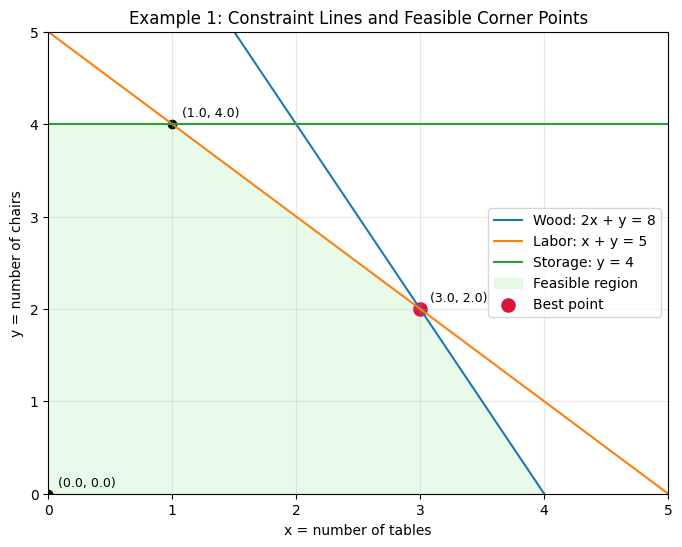

In [7]:
# Visualize the constraint lines, feasible corner points, and best point for Example 1.
try:
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.linspace(0, 5, 400)
    wood_y = 8 - 2 * x          # 2x + y = 8
    labor_y = 5 - x            # x + y = 5
    storage_y = np.full_like(x, 4.0)  # y = 4

    plt.figure(figsize=(8, 6))
    plt.plot(x, wood_y, label='Wood: 2x + y = 8')
    plt.plot(x, labor_y, label='Labor: x + y = 5')
    plt.plot(x, storage_y, label='Storage: y = 4')

    feasible_polygon = np.array([(0, 0), (4, 0), (3, 2), (1, 4), (0, 4)])
    plt.fill(feasible_polygon[:, 0], feasible_polygon[:, 1], alpha=0.2, color='lightgreen', label='Feasible region')

    for px, py in product_points:
        plt.scatter(px, py, color='black')
        plt.text(px + 0.08, py + 0.08, f'({px}, {py})', fontsize=9)

    best = product_ranked[0]['point']
    plt.scatter(best[0], best[1], color='crimson', s=90, label='Best point')

    plt.xlim(0, 5)
    plt.ylim(0, 5)
    plt.xlabel('x = number of tables')
    plt.ylabel('y = number of chairs')
    plt.title('Example 1: Constraint Lines and Feasible Corner Points')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
except ModuleNotFoundError:
    print('matplotlib or numpy is not installed, so the plot was skipped.')
    print('Feasible corner points:', product_points)
    print('Best point:', product_ranked[0])


The candidate corner points are the interesting ones here. The best one should appear at the top of `product_ranked`.

Interpretation: if the best point is `(3, 2)`, then making 3 tables and 2 chairs gives a profit of `40*3 + 30*2 = 180`.


## Example 2: Advertising Budget Allocation

Let:

- `x`: number of social media ad bundles
- `y`: number of radio ad bundles

Goal: maximize reach `5x + 8y`

Constraints:

- Budget: `x + 2y <= 8`
- Staff time: `3x + 2y <= 12`
- `x, y >= 0`


In [3]:
ad_constraints = [
    (1, 2, 8),
    (3, 2, 12),
]
ad_objective = (5, 8)

ad_points = feasible_corner_points(ad_constraints)
ad_ranked = best_point(ad_points, ad_objective, sense='max')
ad_ranked


[{'point': (2.0, 3.0), 'objective': 34.0},
 {'point': (0.0, 0.0), 'objective': 0.0}]

This example shows the same pattern: once the feasible region is defined by linear inequalities, a best solution often sits at a corner point.

That corner-point idea is one reason linear programming is so structured and efficient to solve.


## Example 3: A Tiny Diet-Style Minimization Problem

Now switch from maximization to minimization.

Imagine we buy two foods:

- `x`: bowls of oatmeal
- `y`: cups of yogurt

Minimize cost `3x + 2y`

Nutrition requirements:

- Protein target: `x + 2y >= 6`
- Fiber target: `2x + y >= 6`
- `x, y >= 0`

Our helper expects `<=` constraints, so we multiply both requirement lines by `-1`.


In [4]:
diet_constraints = [
    (-1, -2, -6),
    (-2, -1, -6),
]
diet_objective = (3, 2)

diet_points = feasible_corner_points(diet_constraints)
diet_ranked = best_point(diet_points, diet_objective, sense='min')
diet_ranked[:5]


[{'point': (2.0, 2.0), 'objective': 10.0}]

The top row now gives the lowest-cost feasible choice.

Notice how changing from maximize to minimize only changes how we rank the corner points. The feasible-region logic stays the same.


## Optional: Solve Example 1 with SciPy

`scipy.optimize.linprog` solves minimization problems, so to maximize profit we minimize the negative profit instead.

This cell is optional and will skip cleanly if SciPy is not available.


In [5]:
try:
    from scipy.optimize import linprog

    result = linprog(
        c=[-40, -30],
        A_ub=[[2, 1], [1, 1], [0, 1]],
        b_ub=[8, 5, 4],
        bounds=[(0, None), (0, None)],
        method='highs',
    )

    {
        'success': result.success,
        'solution': tuple(round(v, 4) for v in result.x),
        'max_profit': round(-result.fun, 4),
    }
except ModuleNotFoundError:
    print('SciPy is not installed, so this optional cell was skipped.')


## Exercises and Pitfalls

Try these:

1. Change the profit in Example 1 from `40x + 30y` to `50x + 20y`. Does the best corner change?
2. Add a new constraint `x <= 2.5` to Example 2. What happens to the optimal point?
3. In Example 3, increase the protein target from `6` to `8`. How does the minimum cost change?

Common pitfalls:

- Mixing up maximize and minimize.
- Forgetting non-negativity constraints.
- Reversing inequality signs when rewriting constraints.


In [6]:
# Exercise scaffold: tweak one example and rerun.
new_objective = (50, 20)
best_point(product_points, new_objective, sense='max')[0]


{'point': (3.0, 2.0), 'objective': 190.0}